# 01 · EDA & Business Insights

> **Audience**: CRO, VP Sales, Revenue Operations  
> **Purpose**: Establish baseline understanding of the data, surface key patterns, and compute both standard and custom metrics that feed downstream analysis.

---

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── visual style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE  = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
WON_CLR  = '#16A34A'
LOST_CLR = '#DC2626'
FIG_DIR  = '../outputs/figures'
import os; os.makedirs(FIG_DIR, exist_ok=True)
print("✓ Setup complete")


✓ Setup complete


## 0 · Data Overview

In [2]:
from src.feature_engineering import build_engineered_dataset

df = build_engineered_dataset(save=True)
print(f"Shape : {df.shape}")
print(f"Period: {df['created_date'].min().date()} → {df['created_date'].max().date()}")
print(f"\nOutcome distribution:")
print(df['outcome'].value_counts())
print(f"\nOverall win rate: {df['won'].mean():.1%}")


[data_loader] Loaded 5,000 rows, 45.3% win rate
[feature_engineering] Saved engineered dataset → c:\Users\Krushna\Documents\Self Study\AI-ML\Project\skygeni-sales-intelligence\notebooks\..\data\processed\deals_engineered.csv
Shape : (5000, 22)
Period: 2023-01-01 → 2024-03-26

Outcome distribution:
outcome
Lost    2737
Won     2263
Name: count, dtype: int64

Overall win rate: 45.3%


In [3]:
# Data quality summary
null_pct = df.isnull().mean() * 100
print("Null % per column:")
print(null_pct[null_pct > 0] if null_pct.any() else "✓ No nulls detected")

print("\nCategorical cardinalities:")
for col in ['industry','region','product_type','lead_source','deal_stage']:
    print(f"  {col:15}: {df[col].nunique()} unique → {df[col].unique().tolist()}")


Null % per column:
✓ No nulls detected

Categorical cardinalities:
  industry       : 5 unique → ['SaaS', 'HealthTech', 'FinTech', 'EdTech', 'Ecommerce']
  region         : 4 unique → ['North America', 'India', 'APAC', 'Europe']
  product_type   : 3 unique → ['Enterprise', 'Core', 'Pro']
  lead_source    : 4 unique → ['Referral', 'Inbound', 'Partner', 'Outbound']
  deal_stage     : 5 unique → ['Qualified', 'Closed', 'Proposal', 'Negotiation', 'Demo']


## 1 · Win Rate Over Time

This is the starting point for our investigation — confirming the CRO's complaint in the data and identifying when the change happened.

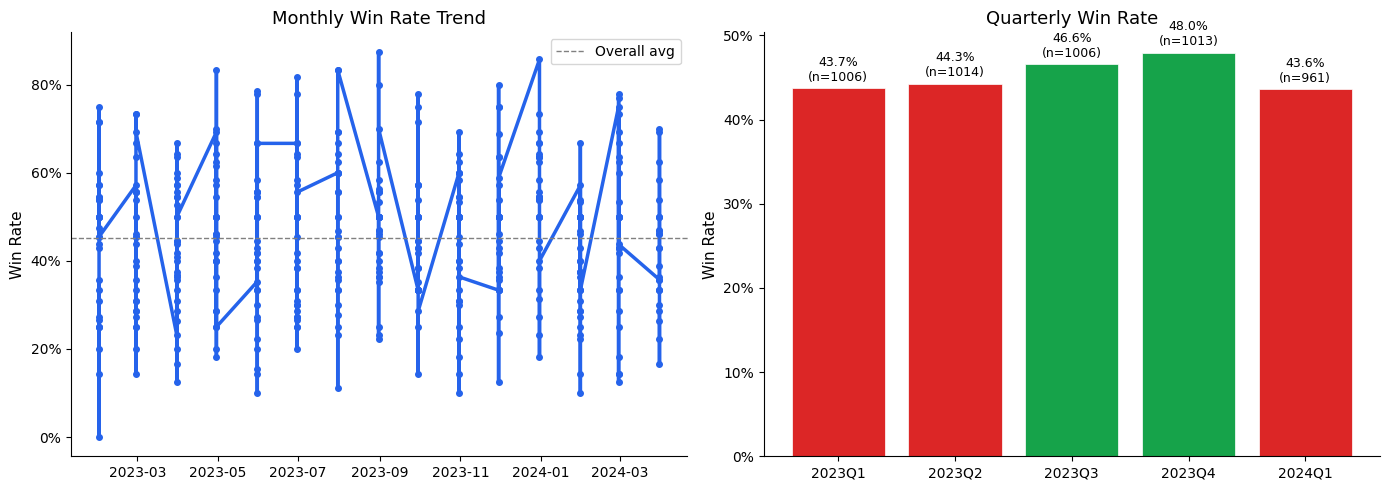


📌 Insight: Win rate was relatively stable through 2023, then dropped in 2024-Q1.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Monthly win rate ──────────────────────────────────────
monthly = df.groupby('created_date').resample('ME', on='created_date').agg(
    win_rate=('won','mean'), deals=('won','count')
).reset_index(level=0, drop=True).reset_index()

ax = axes[0]
ax.plot(monthly['created_date'], monthly['win_rate'], color=PALETTE[0], linewidth=2.5, marker='o', markersize=4)
ax.axhline(monthly['win_rate'].mean(), color='grey', linestyle='--', linewidth=1, label='Overall avg')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Monthly Win Rate Trend')
ax.set_xlabel('')
ax.set_ylabel('Win Rate')
ax.legend()

# ── Quarterly win rate ────────────────────────────────────
q_wr = df.groupby('created_quarter').agg(
    win_rate=('won','mean'), deals=('won','count')
).reset_index()

ax2 = axes[1]
bars = ax2.bar(q_wr['created_quarter'], q_wr['win_rate'],
               color=[WON_CLR if w >= 0.45 else LOST_CLR for w in q_wr['win_rate']],
               edgecolor='white', linewidth=0.5)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title('Quarterly Win Rate')
ax2.set_ylabel('Win Rate')
# Annotate bars
for bar, (_, row) in zip(bars, q_wr.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{row['win_rate']:.1%}\n(n={row['deals']})",
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_win_rate_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Insight: Win rate was relatively stable through 2023, then dropped in 2024-Q1.")


## 2 · Win Rate by Segment

We now decompose win rate across every dimension to identify which segments are underperforming and by how much.

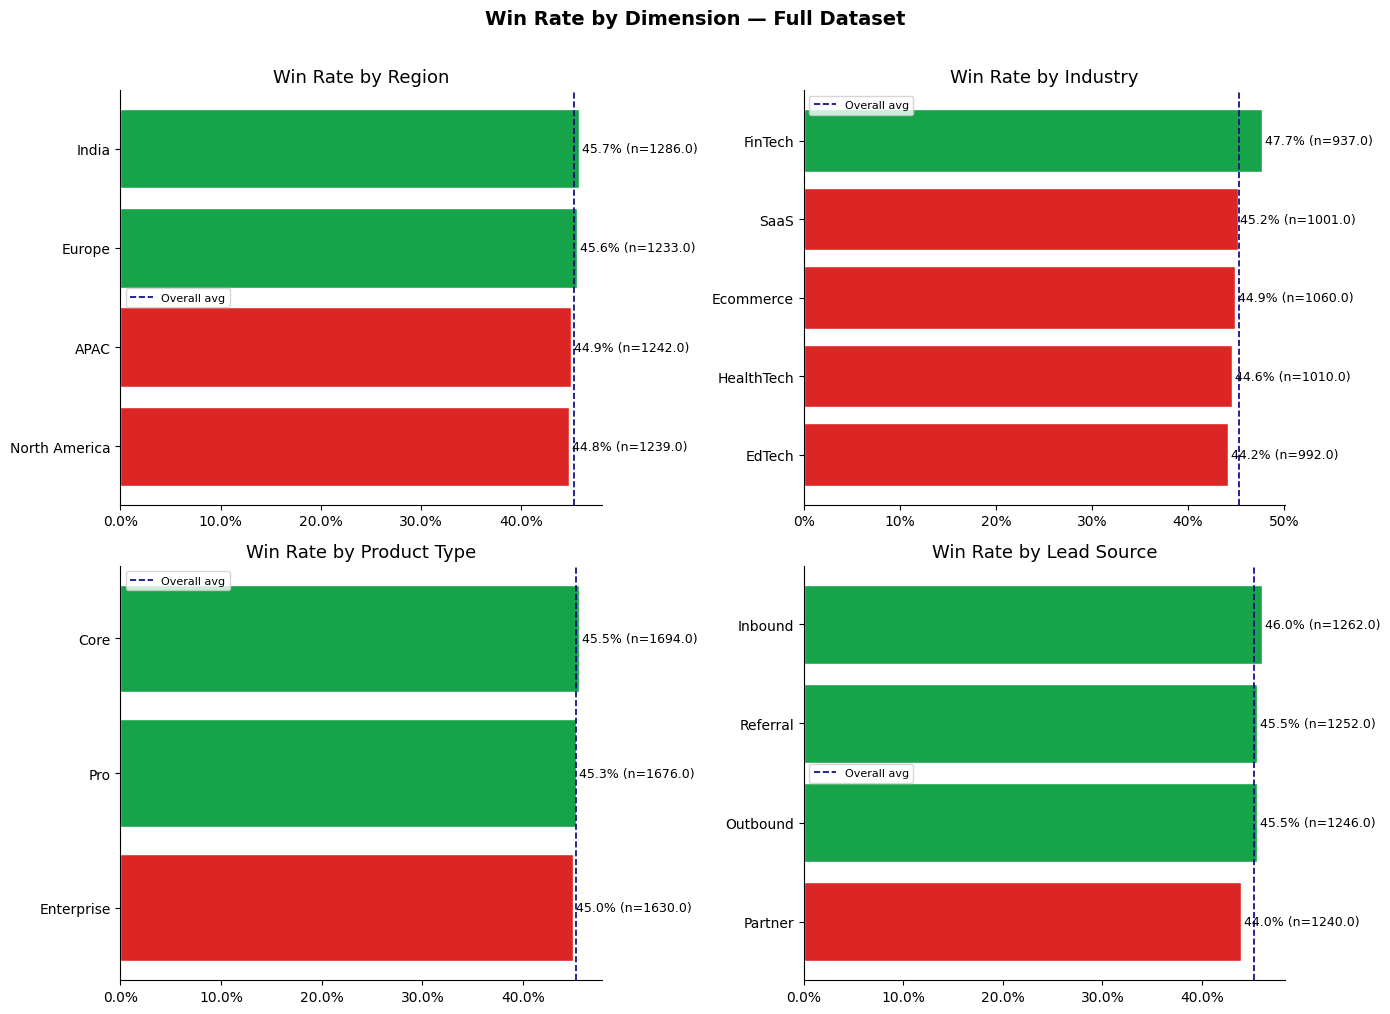

In [5]:
DIMS = ['region', 'industry', 'product_type', 'lead_source']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, dim in zip(axes.flatten(), DIMS):
    seg = df.groupby(dim).agg(
        win_rate=('won','mean'),
        deals=('won','count'),
    ).sort_values('win_rate', ascending=True)

    colors = [WON_CLR if w >= df['won'].mean() else LOST_CLR for w in seg['win_rate']]
    bars = ax.barh(seg.index, seg['win_rate'], color=colors, edgecolor='white')
    ax.axvline(df['won'].mean(), color='navy', linestyle='--', linewidth=1.2, label='Overall avg')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f'Win Rate by {dim.replace("_"," ").title()}')
    for bar, (idx, row) in zip(bars, seg.iterrows()):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f"{row['win_rate']:.1%} (n={row['deals']})",
                va='center', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Win Rate by Dimension — Full Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_win_rate_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()


## 3 · Cross-Segment Heatmap

Some of the most important signals are in the *interactions* between dimensions, not in each dimension alone.

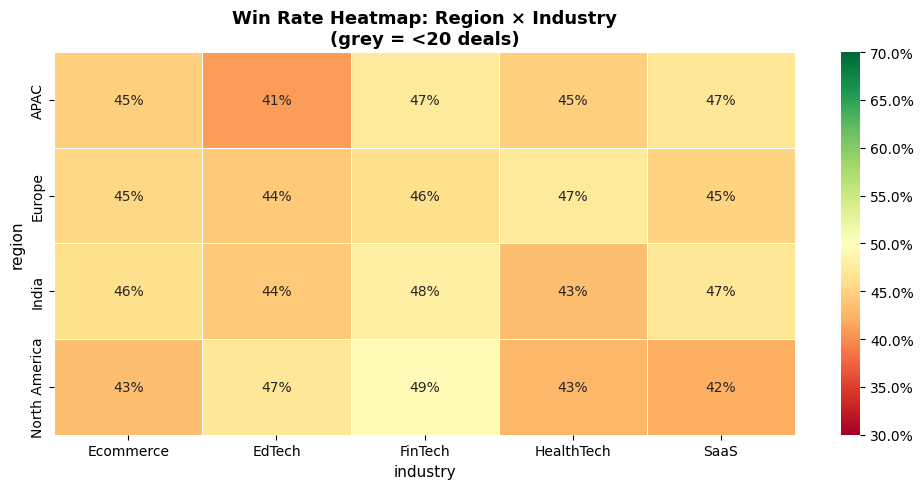


📌 The heatmap reveals which specific Region × Industry combinations are weakest.


In [6]:
from src.win_rate_analyzer import cross_segment_win_rates

pivot = cross_segment_win_rates(df, dim1='region', dim2='industry', min_deals=20)

fig, ax = plt.subplots(figsize=(10, 5))
mask = pivot.isnull()
sns.heatmap(
    pivot, annot=True, fmt='.0%', cmap='RdYlGn',
    vmin=0.3, vmax=0.7, linewidths=0.5,
    mask=mask, ax=ax, cbar_kws={'format': mtick.PercentFormatter(1.0)},
)
ax.set_title('Win Rate Heatmap: Region × Industry\n(grey = <20 deals)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_win_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 The heatmap reveals which specific Region × Industry combinations are weakest.")


## 4 · Rep Performance Analysis

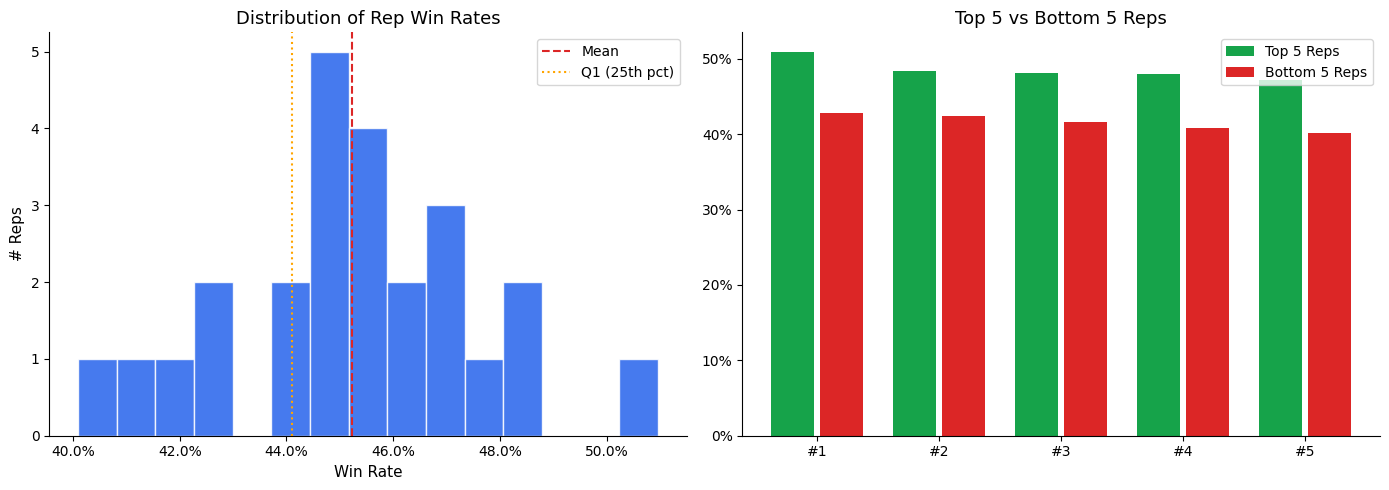


Top 5 rep avg win rate:    48.5%
Bottom 5 rep avg win rate: 41.6%
Performance gap:           7.0%


In [7]:
rep_stats = df.groupby('sales_rep_id').agg(
    win_rate=('won','mean'),
    deals=('won','count'),
    avg_deal=('deal_amount','mean'),
    total_revenue=('deal_amount', lambda x: x[df.loc[x.index,'won']==1].sum()),
).sort_values('win_rate', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of rep win rates
ax = axes[0]
ax.hist(rep_stats['win_rate'], bins=15, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(rep_stats['win_rate'].mean(), color=LOST_CLR, linestyle='--', linewidth=1.5, label='Mean')
ax.axvline(rep_stats['win_rate'].quantile(0.25), color='orange', linestyle=':', linewidth=1.5, label='Q1 (25th pct)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Distribution of Rep Win Rates')
ax.set_xlabel('Win Rate')
ax.set_ylabel('# Reps')
ax.legend()

# Top vs bottom reps
ax2 = axes[1]
top5    = rep_stats.head(5)
bottom5 = rep_stats.tail(5)
x = range(5)
ax2.bar([i - 0.2 for i in x], top5['win_rate'],    width=0.35, label='Top 5 Reps',    color=WON_CLR)
ax2.bar([i + 0.2 for i in x], bottom5['win_rate'], width=0.35, label='Bottom 5 Reps', color=LOST_CLR)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax2.set_title('Top 5 vs Bottom 5 Reps')
ax2.set_xticks(list(x))
ax2.set_xticklabels([f'#{i+1}' for i in x])
ax2.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_rep_performance.png', dpi=150, bbox_inches='tight')
plt.show()

top_wr    = rep_stats.head(5)['win_rate'].mean()
bottom_wr = rep_stats.tail(5)['win_rate'].mean()
print(f"\nTop 5 rep avg win rate:    {top_wr:.1%}")
print(f"Bottom 5 rep avg win rate: {bottom_wr:.1%}")
print(f"Performance gap:           {top_wr - bottom_wr:.1%}")


## 5 · Custom Metrics

These five metrics go beyond standard reporting to surface deeper business signals.

### Custom Metric 1 – Win Rate Momentum Score

Measures the *rate of change* of win rate, not just the current level. A momentum score < −1.5 is an early warning signal that should trigger investigation, even if the absolute win rate hasn't fallen below threshold yet.

created_quarter  win_rate  momentum_raw  momentum_score
         2023Q1  0.437376           NaN             NaN
         2023Q2  0.442801           NaN             NaN
         2023Q3  0.466203      0.028827        1.881749
         2023Q4  0.479763      0.036962        1.856866
         2024Q1  0.436004     -0.030199       -1.483772


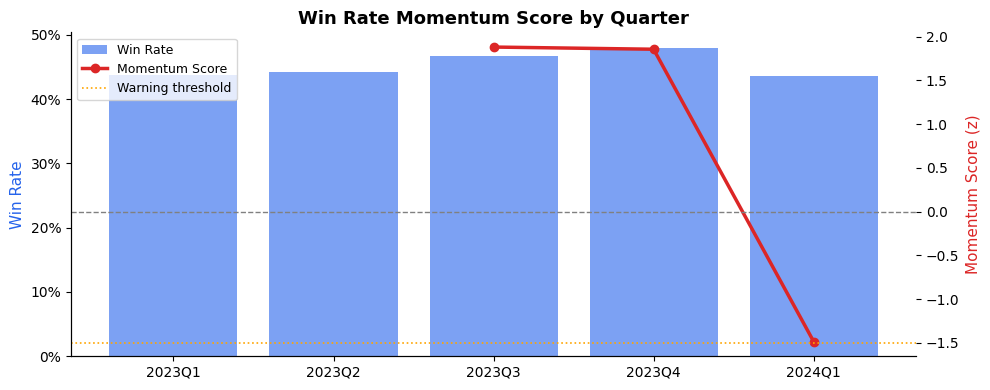


📌 Negative momentum in 2024-Q1 would have been detectable a quarter earlier.


In [8]:
from src.feature_engineering import compute_win_rate_momentum

momentum = compute_win_rate_momentum(df)
print(momentum[['created_quarter','win_rate','momentum_raw','momentum_score']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax2 = ax.twinx()

ax.bar(momentum['created_quarter'], momentum['win_rate'], color=PALETTE[0], alpha=0.6, label='Win Rate')
ax2.plot(momentum['created_quarter'], momentum['momentum_score'],
         color=LOST_CLR, linewidth=2.5, marker='o', label='Momentum Score')
ax2.axhline(0, color='grey', linestyle='--', linewidth=1)
ax2.axhline(-1.5, color='orange', linestyle=':', linewidth=1.2, label='Warning threshold')

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Win Rate', color=PALETTE[0])
ax2.set_ylabel('Momentum Score (z)', color=LOST_CLR)
ax.set_title('Win Rate Momentum Score by Quarter', fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_momentum_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Negative momentum in 2024-Q1 would have been detectable a quarter earlier.")


### Custom Metric 2 – Deal Mix Shift Index

Tests for Simpson's Paradox: separates 'we converted worse' from 'we started chasing harder deals'. This is the most important diagnostic metric for correctly attributing the win rate decline.

In [9]:
from src.feature_engineering import compute_deal_mix_shift

for dim in ['region', 'industry', 'product_type', 'lead_source']:
    mix = compute_deal_mix_shift(df, dim)
    print(f"\n── {dim.upper()} ──────────────────────────────────────────")
    print(f"  Total WR change:    {mix.attrs['overall_wr_change']*100:+.2f}pp")
    print(f"  Conversion effect:  {mix.attrs['conversion_effect']*100:+.2f}pp  ← are we selling worse?")
    print(f"  Mix shift effect:   {mix.attrs['mix_effect']*100:+.2f}pp  ← did we change what we pursue?")
    print(mix[['segment','base_share','comp_share','mix_shift','base_win_rate','comp_win_rate','wr_change']].to_string(index=False))
print("\n📌 If mix_shift_effect is large → fix targeting strategy, not sales coaching.")



── REGION ──────────────────────────────────────────
  Total WR change:    -2.05pp
  Conversion effect:  -2.04pp  ← are we selling worse?
  Mix shift effect:   -0.01pp  ← did we change what we pursue?
      segment  base_share  comp_share  mix_shift  base_win_rate  comp_win_rate  wr_change
        India    0.259223    0.248699  -0.010523       0.456543       0.460251   0.003709
         APAC    0.248329    0.248699   0.000370       0.453639       0.430962  -0.022677
       Europe    0.247586    0.242456  -0.005130       0.464000       0.420601  -0.043399
North America    0.244863    0.260146   0.015283       0.451972       0.432000  -0.019972

── INDUSTRY ──────────────────────────────────────────
  Total WR change:    -2.05pp
  Conversion effect:  -2.10pp  ← are we selling worse?
  Mix shift effect:   +0.04pp  ← did we change what we pursue?
   segment  base_share  comp_share  mix_shift  base_win_rate  comp_win_rate  wr_change
 Ecommerce    0.213667    0.204995  -0.008672       0.450

### Custom Metric 3 – Rep Performance Divergence Index

created_quarter  top_q_wr  bottom_q_wr  divergence_index  overall_wr
         2023Q1  0.470588     0.400000          0.070588    0.435784
         2023Q2  0.500000     0.369565          0.130435    0.444854
         2023Q3  0.511111     0.428571          0.082540    0.467988
         2023Q4  0.514286     0.435897          0.078388    0.479321
         2024Q1  0.456522     0.394737          0.061785    0.434819


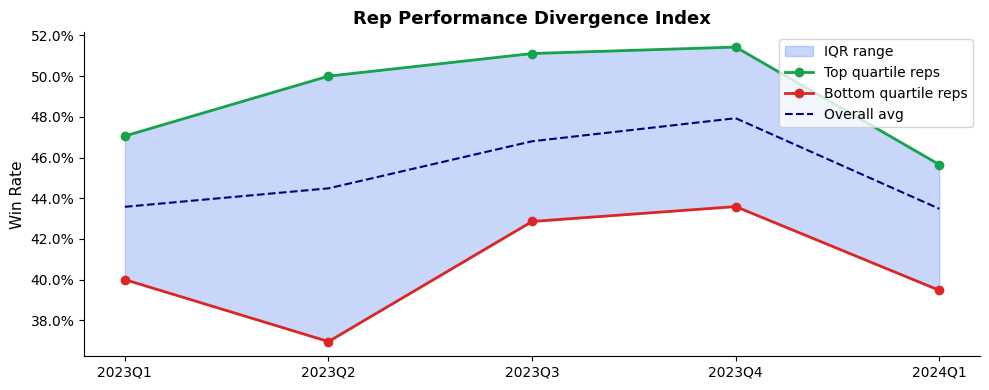


📌 Widening gap = coaching problem. Narrowing gap = top reps declining too.


In [10]:
from src.feature_engineering import compute_rep_divergence

div = compute_rep_divergence(df)
print(div[['created_quarter','top_q_wr','bottom_q_wr','divergence_index','overall_wr']].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(div['created_quarter'], div['bottom_q_wr'], div['top_q_wr'],
                alpha=0.25, color=PALETTE[0], label='IQR range')
ax.plot(div['created_quarter'], div['top_q_wr'],    color=WON_CLR,  linewidth=2, marker='o', label='Top quartile reps')
ax.plot(div['created_quarter'], div['bottom_q_wr'], color=LOST_CLR, linewidth=2, marker='o', label='Bottom quartile reps')
ax.plot(div['created_quarter'], div['overall_wr'],  color='navy',   linewidth=1.5, linestyle='--', label='Overall avg')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Rep Performance Divergence Index', fontweight='bold')
ax.set_ylabel('Win Rate')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_rep_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Widening gap = coaching problem. Narrowing gap = top reps declining too.")


### Custom Metric 4 – Stage Velocity Score

      stage  base_avg_days  curr_avg_days  stage_win_rate  days_delta  velocity_score  weighted_impact
     Closed      64.262958      61.728155        0.476612   -2.534803        2.534803         1.208117
       Demo      63.712085      65.030151        0.460900    1.318065       -1.318065        -0.607497
Negotiation      62.989950      65.301508        0.471106    2.311558       -2.311558        -1.088988
   Proposal      62.113909      65.022857        0.459233    2.908948       -2.908948        -1.335884
  Qualified      65.192506      64.401099        0.413437   -0.791408        0.791408         0.327197


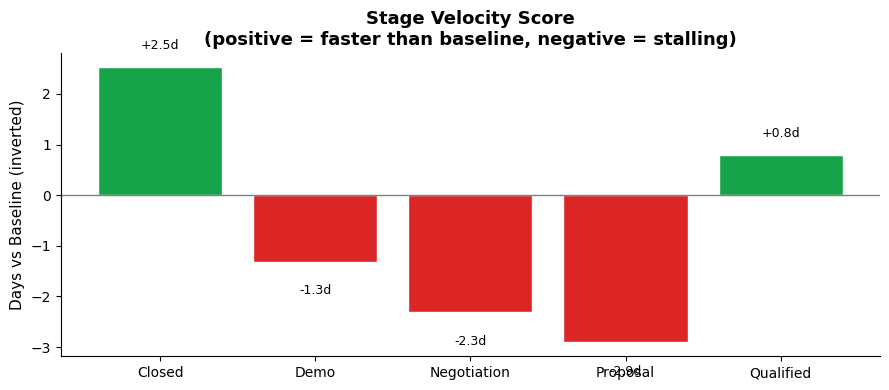

In [11]:
from src.feature_engineering import compute_stage_velocity

velocity = compute_stage_velocity(df)
print(velocity.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [WON_CLR if v > 0 else LOST_CLR for v in velocity['velocity_score']]
bars = ax.bar(velocity['stage'], velocity['velocity_score'], color=colors, edgecolor='white')
ax.axhline(0, color='grey', linewidth=1)
ax.set_title('Stage Velocity Score\n(positive = faster than baseline, negative = stalling)', fontweight='bold')
ax.set_ylabel('Days vs Baseline (inverted)')
for bar, v in zip(bars, velocity['velocity_score']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.3 if v >= 0 else -0.7),
            f"{v:+.1f}d", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_stage_velocity.png', dpi=150, bbox_inches='tight')
plt.show()


### Custom Metric 5 – Lead Source Quality Decay

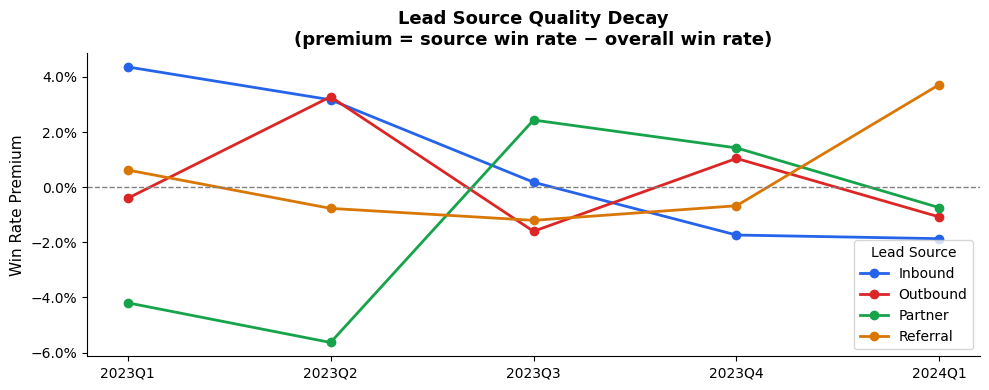


📌 If all sources decay → product/market problem. Only one source → channel issue.


In [12]:
from src.feature_engineering import compute_lead_source_decay

decay = compute_lead_source_decay(df)

fig, ax = plt.subplots(figsize=(10, 4))
for i, src in enumerate(decay['lead_source'].unique()):
    sub = decay[decay['lead_source'] == src].sort_values('created_quarter')
    ax.plot(sub['created_quarter'], sub['premium'],
            marker='o', linewidth=2, label=src, color=PALETTE[i])
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Lead Source Quality Decay\n(premium = source win rate − overall win rate)', fontweight='bold')
ax.set_ylabel('Win Rate Premium')
ax.legend(title='Lead Source')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_lead_source_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 If all sources decay → product/market problem. Only one source → channel issue.")


## 6 · Business Insights Summary

Below are the top insights in plain business language, each tied to a specific recommended action.

In [13]:
from src.win_rate_analyzer import generate_insights

insights = generate_insights(df)
print("=" * 65)
print("TOP BUSINESS INSIGHTS")
print("=" * 65)
for i, insight in enumerate(insights, 1):
    print(f"\n[{i}] {insight}")


TOP BUSINESS INSIGHTS

[1] Overall win rate changed from 45.6% (2023 baseline) to 43.6% (2024-Q1), a shift of -2.1 percentage points.

[2] 'Europe' (region) showed the largest win-rate decline: -4.3pp, representing an estimated $270,725 revenue impact.

[3] 'EdTech' (industry) showed the largest win-rate decline: -3.5pp, representing an estimated $183,086 revenue impact.

[4] 'Enterprise' (product_type) showed the largest win-rate decline: -4.1pp, representing an estimated $318,291 revenue impact.

[5] 'Inbound' (lead_source) showed the largest win-rate decline: -5.4pp, representing an estimated $372,059 revenue impact.


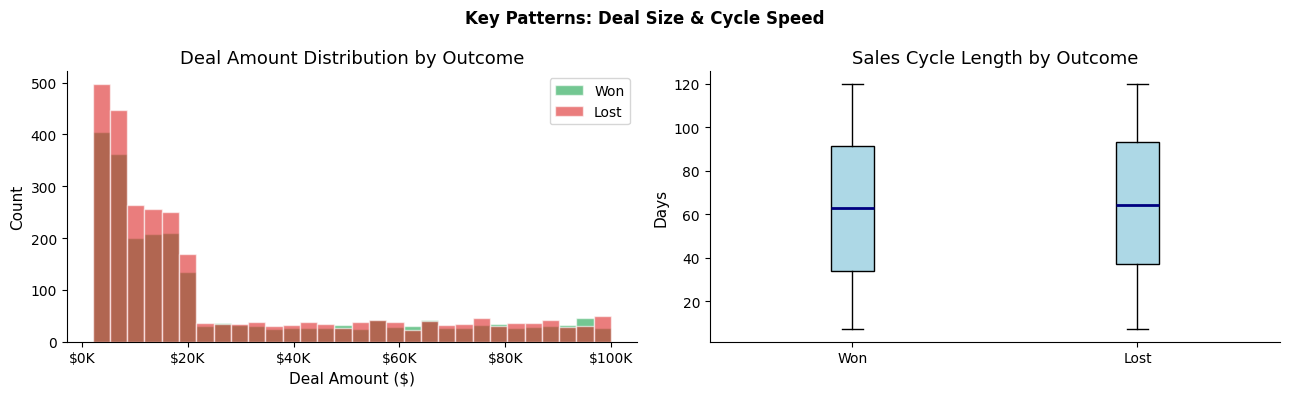

Won deals avg cycle:  63 days
Lost deals avg cycle: 64 days


In [14]:
# ── Insight 1: Deal amount distribution by outcome ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
for outcome, color, label in [('Won', WON_CLR, 'Won'), ('Lost', LOST_CLR, 'Lost')]:
    sub = df[df['outcome'] == outcome]['deal_amount']
    ax.hist(sub, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
ax.set_title('Deal Amount Distribution by Outcome')
ax.set_xlabel('Deal Amount ($)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.legend()

# ── Insight 2: Sales cycle by outcome ────────────────────────
ax2 = axes[1]
won_cycle  = df[df['won']==1]['sales_cycle_days']
lost_cycle = df[df['won']==0]['sales_cycle_days']
ax2.boxplot([won_cycle, lost_cycle], labels=['Won', 'Lost'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='navy', linewidth=2))
ax2.set_title('Sales Cycle Length by Outcome')
ax2.set_ylabel('Days')

plt.suptitle('Key Patterns: Deal Size & Cycle Speed', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_deal_size_and_cycle.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Won deals avg cycle:  {won_cycle.mean():.0f} days")
print(f"Lost deals avg cycle: {lost_cycle.mean():.0f} days")


---

## Summary

This EDA notebook established:
1. Win rate trend and the timing of the decline
2. Which dimensions show the largest performance gaps
3. Five custom metrics that go beyond standard reporting

**→ Proceed to Notebook 02 for the full Win Rate Driver Analysis.**